In [16]:
import pyclara
import ocelot
from ocelot.gui.accelerator import *
import sdds

In [17]:
oc = xsuite_twiss = pyclara.Converters.elegant2ocelot("../PostInjector/FEBE.lte",
                                                      start_element="CLA-FEA-SIM-DIP-04-END",
                                                      end_element="CLA-FED-SIM-DUMP-01-START",
                                                      elegant_twi="../Run/FEBE.twi")


/var/folders/cl/6r5v7q4s67sft4z1ndz9kmw80000gq/T/ipykernel_27898/91099942.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/cl/6r5v7q4s67sft4z1ndz9kmw80000gq/T/ipykernel_27898/91099942.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


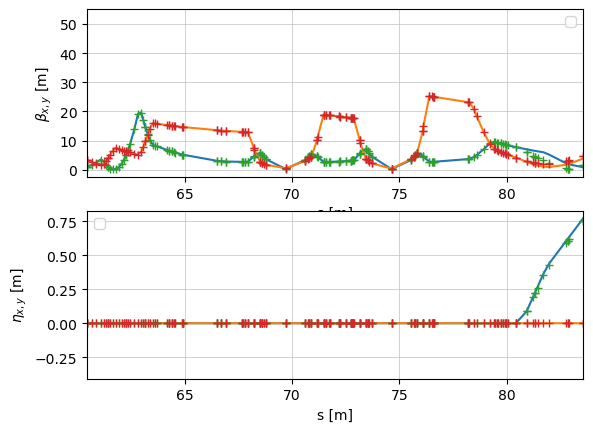

In [39]:
elegant_twi = sdds.load("../Run/FEBE.twi")

e_names = np.array(elegant_twi.getColumnValueList("ElementName"))
e_s = np.array(elegant_twi.getColumnValueList("s"))
e_betax = np.array(elegant_twi.getColumnValueList("betax"))
e_betay = np.array(elegant_twi.getColumnValueList("betay"))
e_etax = np.array(elegant_twi.getColumnValueList("etax"))
e_etay = np.array(elegant_twi.getColumnValueList("etay"))

e_idx0 = np.where(e_names == "CLA-FEA-SIM-DIP-04-END")[0] # TODO not sure about this offset 
e_idxN = np.where(e_names == "CLA-FED-SIM-DUMP-01-START")[0]
elegant_twi.getColumnValueList("ElementName")

o_s = [] 
o_betax = []
o_betay = []
o_Dx = []
o_Dy = []

for t in oc['ocelot_twiss'] :
    o_s.append(t.s)
    o_betax.append(t.beta_x)
    o_betay.append(t.beta_y)
    o_Dx.append(t.Dx)
    o_Dy.append(t.Dy)

plt.subplot(2,1,1)
plt.plot(e_s, e_betax)
plt.plot(e_s, e_betay)
plt.plot(o_s + e_s[e_idx0] ,o_betax,"+")
plt.plot(o_s + e_s[e_idx0] ,o_betay,"+")
plt.xlabel("s [m]")
plt.ylabel("$\\beta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend()

plt.subplot(2,1,2)
plt.plot(e_s, e_etax)
plt.plot(e_s, e_etay)
plt.plot(o_s + e_s[e_idx0] ,o_Dx,"+")
plt.plot(o_s + e_s[e_idx0] ,o_Dy,"+")
plt.xlabel("s [m]")
plt.ylabel("$\\eta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend()


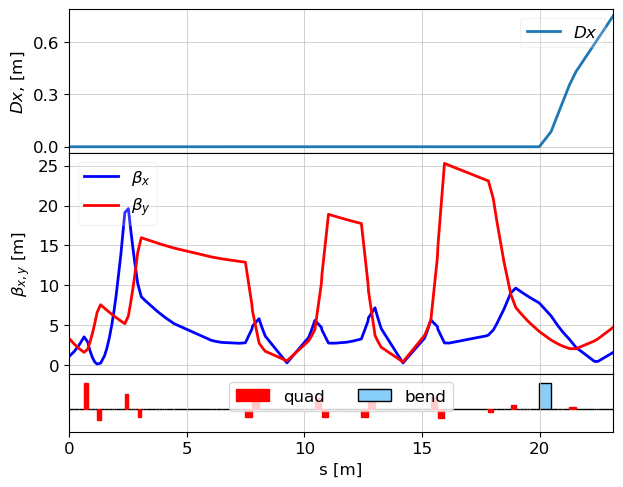

In [37]:
plot_opt_func(oc['ocelot_lattice'],oc['ocelot_twiss'])